# Numerical Simulation Laboratory - Notebook 1

In [15]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

## Excercise 01.1

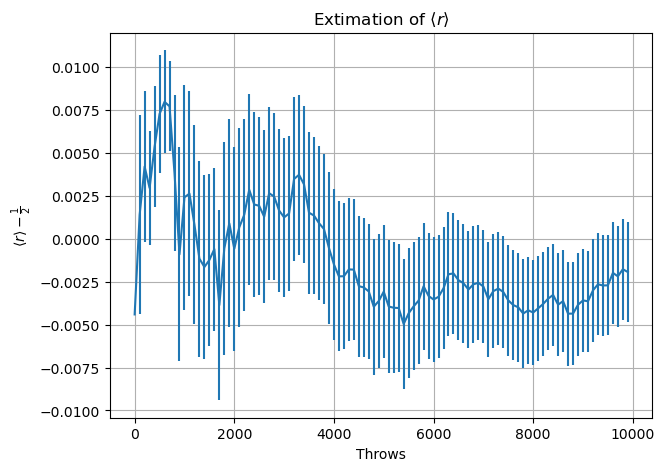

In [16]:
data = np.loadtxt("../01-Exercises/OUTPUT/averages.out")
averages = data[:, 0]
errors = data[:, 1]
L = 100

x = np.arange(averages.size) * L

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.errorbar(x, averages - 0.5, yerr=errors)
ax.set_title(r"Extimation of $\langle r\rangle$")
ax.set_xlabel("Throws")
ax.set_ylabel(r"$\langle r\rangle-\frac{1}{2}$")
ax.grid();

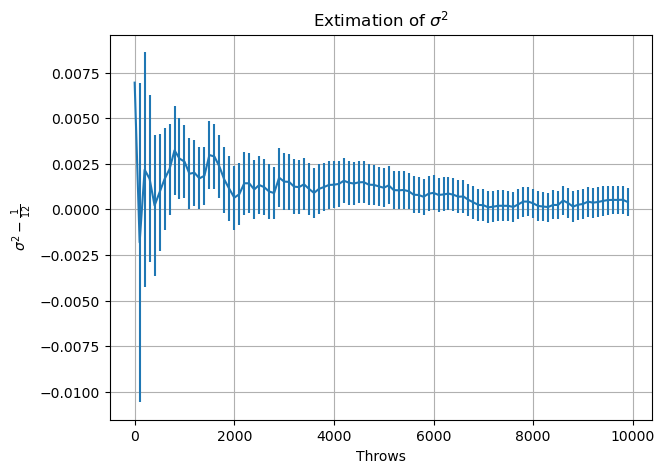

In [17]:
data = np.loadtxt("../01-Exercises/OUTPUT/variances.out")
variances = data[:, 0]
errors = data[:, 1]
L = 100

x = np.arange(variances.size) * L

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.errorbar(x, variances - 1./12., yerr=errors)
ax.set_title(r"Extimation of $\sigma^2$")
ax.set_xlabel("Throws")
ax.set_ylabel(r"$\sigma^2-\frac{1}{12}$")
ax.grid();

In [18]:
def chi_2_dist(x, k):
    return np.power(x, k*0.5-1)*np.exp(-x*0.5)/(np.power(2, k*0.5)*math.gamma(k*0.5))

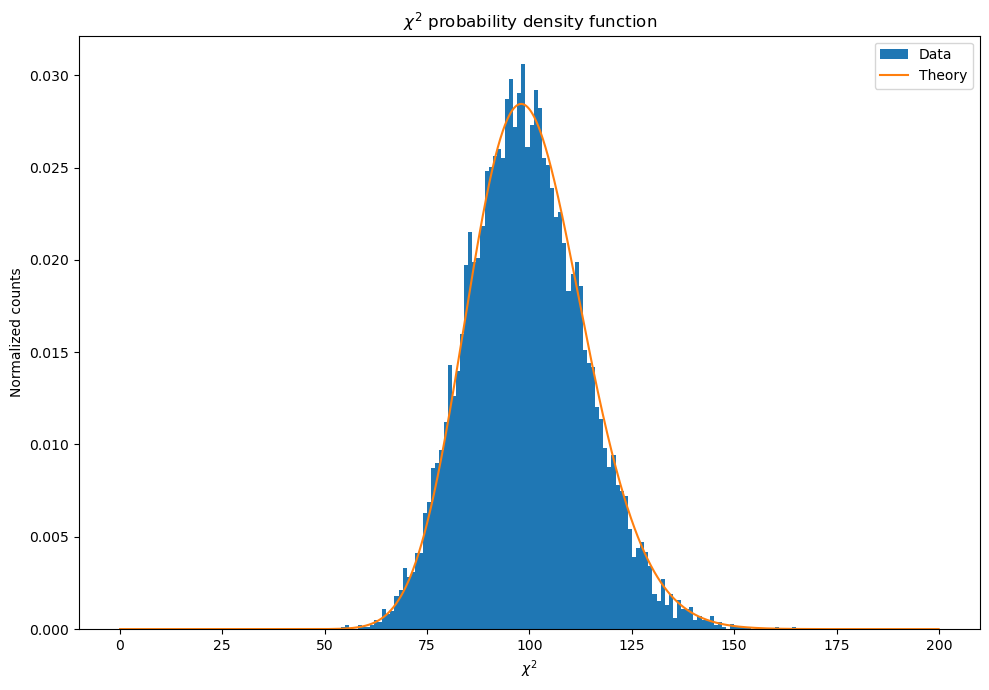

In [19]:
chi2 = np.loadtxt("../01-Exercises/OUTPUT/chi2.out")

fig, ax = plt.subplots(1, 1, figsize=(10,7))
xmin, xmax = 0.1, 200
nbins = 200
x = np.arange(xmin, xmax, 0.1)

ax.hist(chi2, bins=nbins, range=(xmin,xmax), density=True, label="Data");
k = 100

ax.plot(x, chi_2_dist(x, k), label="Theory");

ax.legend()
ax.set_title(r"$\chi^2$ probability density function")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel("Normalized counts");

plt.tight_layout();

Both the mean and the variance of the uniform ditribution generated by the random number generator are compatibile with their expected values. 
The numerical $\chi^2$ measurements fit the theoretical $\chi^2$ probability distribution function with $100$ degrees of freedom.

## Excercise 01.2

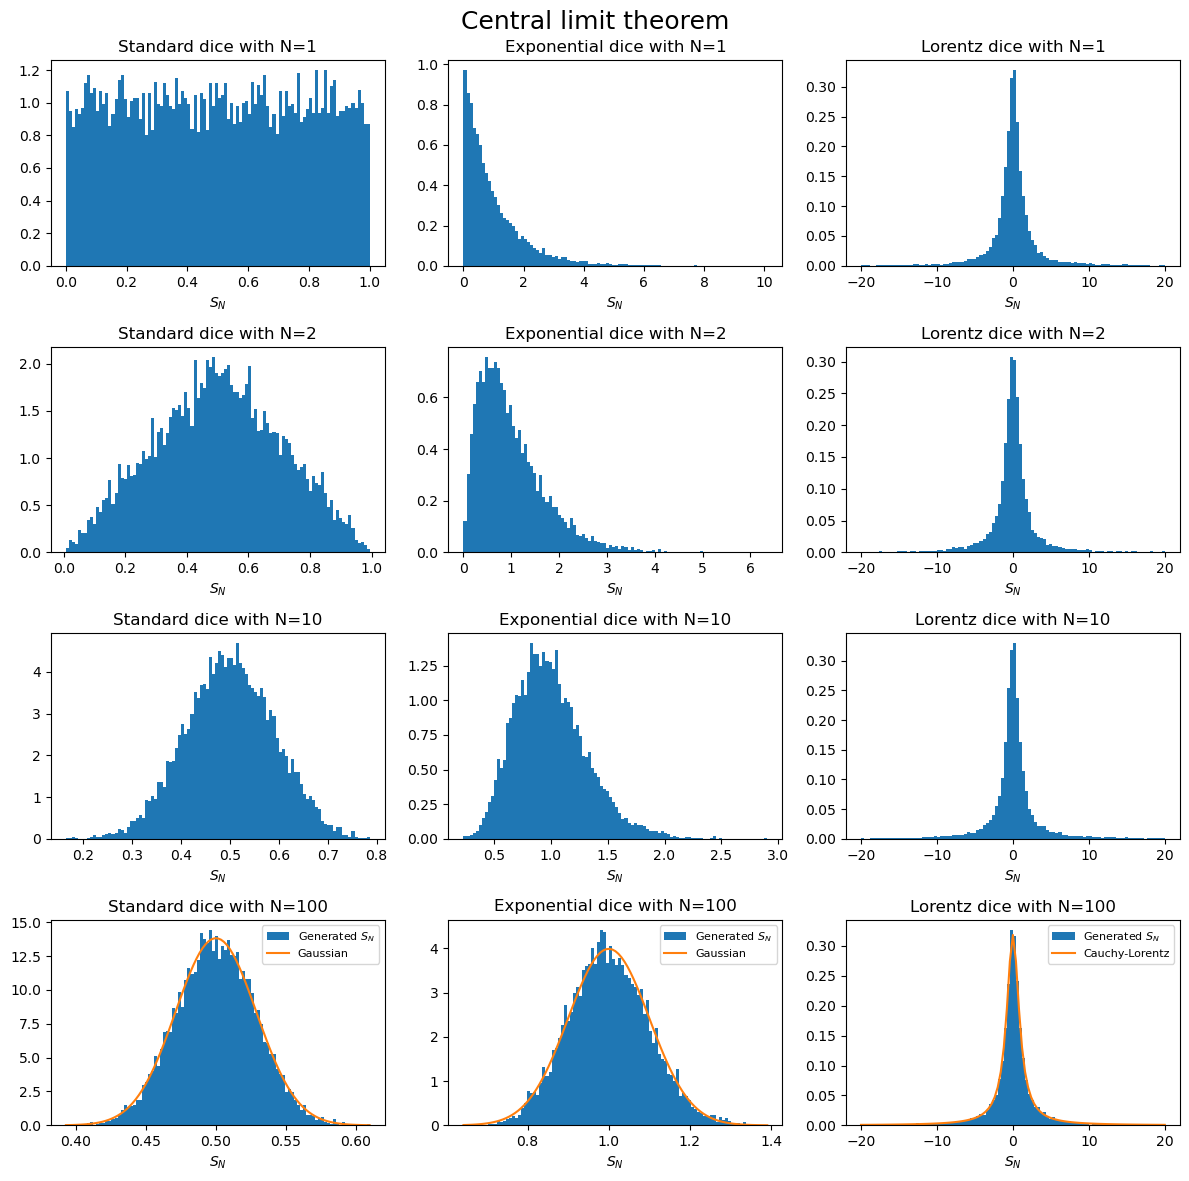

In [20]:
N = [1, 2, 10, 100]
nbins = 100
nsamples = 10000

fig, axs = plt.subplots(4, 3, figsize=(12,12))
fig.suptitle("Central limit theorem", fontsize=18)

for row, n in enumerate(N):
    data = np.loadtxt(f"../01-Exercises/OUTPUT/{n}.out")
    standard, exp, lorentz = data[:,0], data[:,1], data[:,2]

    _, bins_standard, _ = axs[row,0].hist(standard, nbins, label="Generated $S_N$", density=True)
    _, bins_exp, _ = axs[row,1].hist(exp, nbins,label="Generated $S_N$", density=True)
    _, bins_lorentz, _ = axs[row,2].hist(lorentz, nbins, range=(-20,20),label="Generated $S_N$", density=True)

    axs[row,0].set_title(f"Standard dice with N={n}")
    axs[row,1].set_title(f"Exponential dice with N={n}")
    axs[row,2].set_title(f"Lorentz dice with N={n}")

    for ax in axs[row,:]:
        ax.set_xlabel("$S_N$")

    # fit theorical distributions for N=100
    if row == 3:
        x = bins_standard
        axs[row,0].plot(x, np.exp(-np.power(x-0.5,2)*n*12./2.)*math.sqrt(n*12./(2.*np.pi)), label="Gaussian")

        x = bins_exp
        axs[row,1].plot(x, np.exp(-np.power(x-1.,2)*n/2.)*math.sqrt(n/(2.*np.pi)), label="Gaussian")

        x = bins_lorentz
        axs[row,2].plot(x, 1./(np.pi*(1+np.power(x,2))), label="Cauchy-Lorentz")

        for ax in axs[row,:]:
            ax.legend(loc="upper right", fontsize=8);

plt.tight_layout();


The figure above shows the effectiveness of the central limit theorem. Both the uniform and the exponential distribution converge to a Gaussian distribution when increasing the number of summed values $N$. The Lorentzian distribution is outside the basin of attraction of the Gaussian function and it converges to itself, as can be seen by the fit of the Lorentzian distribution on the generated data.

## Excercise 01.3

To generate the angle of the needle the program generates uniformly a set of coordinates $(x,y)$ inside a square with unitary side and then checks whether the point is inside the circle inscribed in the square. This generates a uniform angle distribution $\theta\in[0,2\pi)$ without the need of knowing the value of $\pi$.

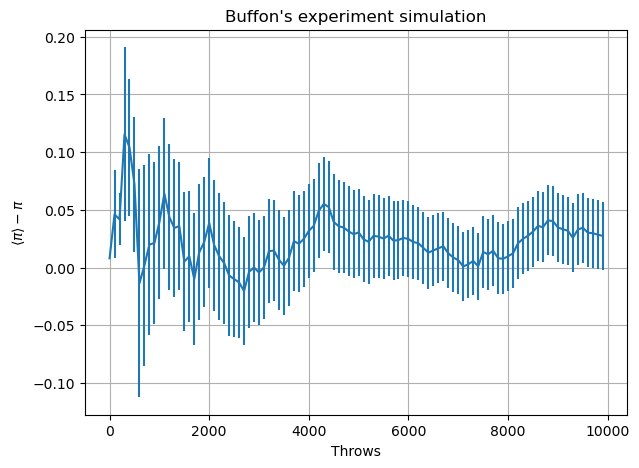

In [21]:
data = np.loadtxt("../01-Exercises/OUTPUT/pi.out")
pi = data[:, 0]
errors = data[:, 1]

x = np.arange(pi.size) * 100

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.errorbar(x, pi - np.pi, yerr=errors)
ax.set_title("Buffon's experiment simulation")
ax.set_xlabel("Throws")
ax.set_ylabel(r"$\langle\pi\rangle-\pi$")
ax.grid()

The outcome of the Buffon experiment converges to the real value of $\pi$, which confirms the validity of the experiment for measuring the value of the constant.